# SmartGridAI — Phase 1 EDA

Weather-Aware Electricity Consumption Forecasting & AI Energy Optimization Platform

**Goal of this notebook:** understand the PJM hourly electricity-load dataset before building any
forecasting model. Every chart below answers a specific question (seasonality, weekly rhythm,
weekday-vs-weekend behaviour, distribution, data quality, autocorrelation for forecast preparation).

In [1]:
import json
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (12, 5)
plt.rcParams["figure.dpi"] = 100

ROOT = Path.cwd() if (Path.cwd() / "ml").exists() else Path.cwd().parent
PROCESSED = ROOT / "ml" / "data" / "processed"
RAW = ROOT / "ml" / "data" / "raw"
print("Project root:", ROOT)

Project root: C:\Users\lisha\Desktop\smartgridai


## 1. Dataset Overview

**Question: what are we working with?** Size, date range, sampling frequency and the exact series
we will model (hourly grid load in MW).

In [2]:
consumption = pd.read_parquet(PROCESSED / "consumption_hourly.parquet")["consumption"]
consumption.index = pd.to_datetime(consumption.index)
consumption = consumption.sort_index()

print(f"Records: {len(consumption):,}")
print(f"Date range: {consumption.index.min()}  ->  {consumption.index.max()}")
print(f"Span: {consumption.index.max() - consumption.index.min()}")
deltas = consumption.index.to_series().diff().dropna()
print(f"Modal interval: {deltas.mode().iloc[0]}")
print(f"Intervals exactly 1h: {(deltas == pd.Timedelta('1h')).mean() * 100:.2f}%")
print(f"Missing values in cleaned series: {int(consumption.isna().sum())}")

# Source / meta
report = json.loads((PROCESSED / "quality_report.json").read_text(encoding="utf-8"))
print("Kaggle slug:", report["dataset"]["kaggle_slug"])
print("Final validation status:", report["final_status"])
print()
consumption.describe().to_frame("hourly load (MW)")

Records: 35,028
Date range: 2014-12-31 23:00:00  ->  2018-12-31 22:00:00
Span: 1460 days 23:00:00
Modal interval: 0 days 01:00:00
Intervals exactly 1h: 99.94%
Missing values in cleaned series: 0
Kaggle slug: nicholasjhana/energy-consumption-generation-prices-and-weather
Final validation status: WARN



,hourly load (MW)
count,35028.000000
mean,28696.939905
std,4574.987950
min,18041.000000
25%,24807.750000
50%,28901.000000
75%,32192.000000
max,41015.000000


## 2. Data Quality Analysis

**Question: can we trust the data?** Missing values, duplicates, gaps and parsing behaviour all
have to be understood before modelling. The cleaned artifact produced by
`validate_dataset.py` is guaranteed gap-free *for the load column*, so this section focuses on the
raw file.

In [3]:
def find_raw_file():
    for cand in [RAW / "energy_dataset.csv", *[d / "energy_dataset.csv" for d in RAW.iterdir() if d.is_dir()]]:
        if cand.exists():
            return cand
    return None

raw_file = find_raw_file()
if raw_file is None:
    raise FileNotFoundError("energy_dataset.csv not found under ml/data/raw/")

df = pd.read_csv(raw_file)
df["time"] = pd.to_datetime(df["time"], utc=True, format="mixed").dt.tz_localize(None)
print(f"Raw shape: {df.shape}  (rows, columns)")
print(f"Duplicate rows: {int(df.duplicated().sum()):,}")
print(f"Duplicate timestamps: {int(df['time'].duplicated().sum()):,}")

missing = df.isna().sum()
missing = missing[missing > 0].sort_values(ascending=False)
print("\nColumns with missing values:")
print(missing.to_string())

target_missing = int(df["total load actual"].isna().sum())
print(f"\nMissing in target 'total load actual': {target_missing:,} ({target_missing / len(df) * 100:.3f}%)")

# Gap analysis on the load series
clean_idx = consumption.index
expected = pd.date_range(clean_idx.min(), clean_idx.max(), freq="h")
actual = set(clean_idx)
gaps = [t for t in expected if t not in actual]
print(f"Missing intervals vs ideal hourly grid: {len(gaps):,} of {len(expected):,}")
print("First 5 gaps:", [str(t) for t in gaps[:5]])

Raw shape: (35064, 29)  (rows, columns)
Duplicate rows: 0
Duplicate timestamps: 0

Columns with missing values:
generation hydro pumped storage aggregated     35064
forecast wind offshore eday ahead              35064
total load actual                                 36
generation hydro pumped storage consumption       19
generation biomass                                19
generation fossil oil                             19
generation marine                                 19
generation hydro run-of-river and poundage        19
generation waste                                  19
generation fossil oil shale                       18
generation fossil coal-derived gas                18
generation fossil brown coal/lignite              18
generation fossil hard coal                       18
generation fossil gas                             18
generation fossil peat                            18
generation solar                                  18
generation hydro water reservoir        

Missing intervals vs ideal hourly grid: 36 of 35,064
First 5 gaps: ['2015-01-05 11:00:00', '2015-01-05 12:00:00', '2015-01-05 13:00:00', '2015-01-05 14:00:00', '2015-01-05 15:00:00']


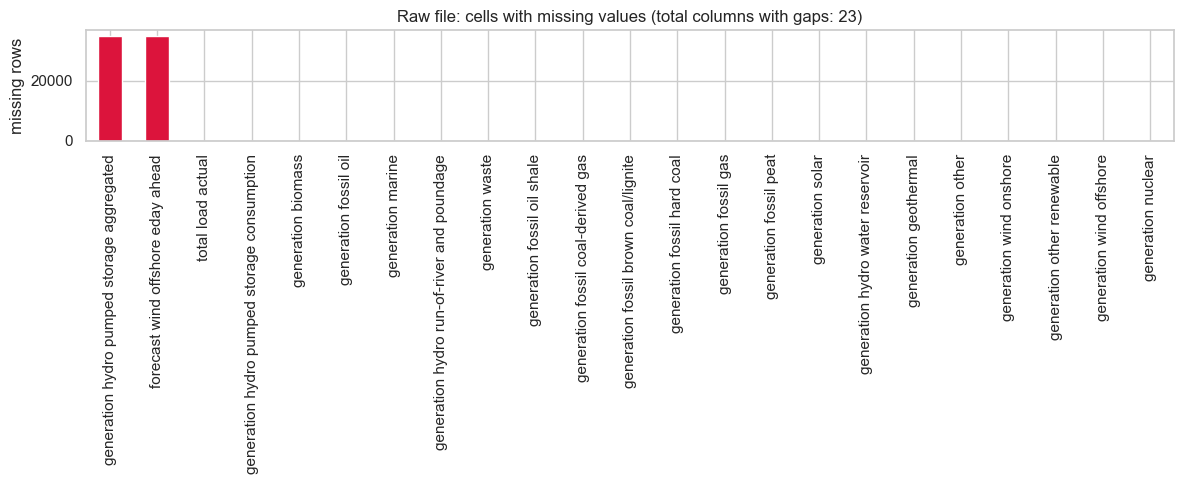

In [4]:
fig, ax = plt.subplots(figsize=(12, 5))
missing = df.isna().sum()
missing = missing[missing > 0].sort_values(ascending=False)
if len(missing):
    missing.plot.bar(ax=ax, color="crimson")
    ax.set_title(f"Raw file: cells with missing values (total columns with gaps: {len(missing)})")
    ax.set_ylabel("missing rows")
else:
    ax.text(0.5, 0.5, "No missing values in raw file", ha="center", fontsize=14)
    ax.set_axis_off()
plt.tight_layout()
plt.show()

## 3. Consumption Distribution

**Question: what does the load look like statistically?** Shape, spread, symmetry, and whether a
normal assumption is safe.

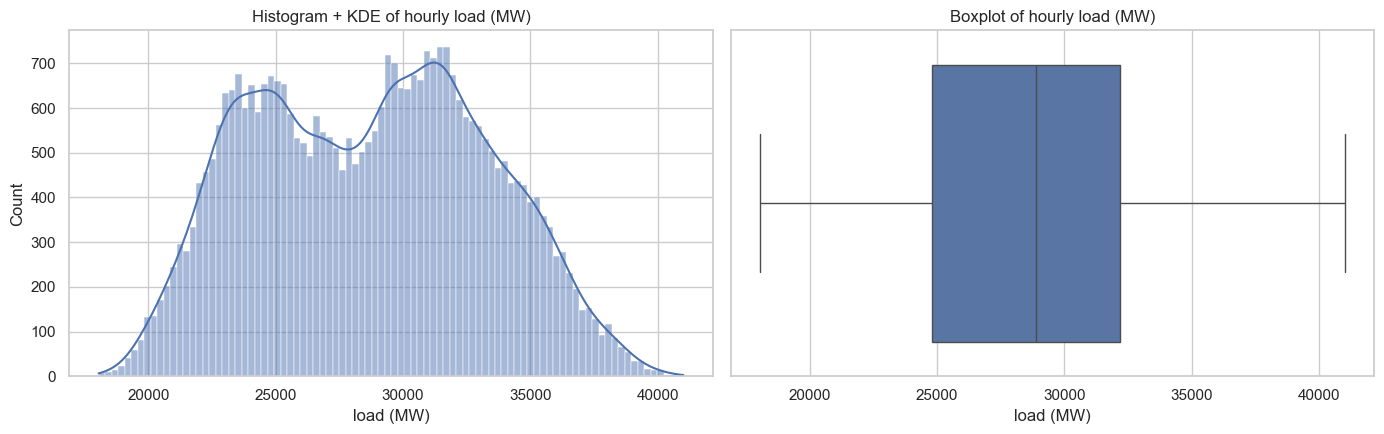

Skewness: 0.062  Kurtosis: -0.915
IQR outliers: 0


In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))
sns.histplot(consumption, bins=90, kde=True, ax=axes[0])
axes[0].set_title("Histogram + KDE of hourly load (MW)")
axes[0].set_xlabel("load (MW)")
sns.boxplot(x=consumption, ax=axes[1])
axes[1].set_title("Boxplot of hourly load (MW)")
axes[1].set_xlabel("load (MW)")
plt.tight_layout()
plt.show()

print("Skewness:", round(float(consumption.skew()), 3), " Kurtosis:", round(float(consumption.kurtosis()), 3))
print("IQR outliers:", int(((consumption < consumption.quantile(0.25) - 1.5 * (consumption.quantile(0.75) - consumption.quantile(0.25)))
                            | (consumption > consumption.quantile(0.75) + 1.5 * (consumption.quantile(0.75) - consumption.quantile(0.25)))).sum()))

## 4. Hourly Consumption Patterns

**Question: when during the day is demand highest/lowest?** The intra-day profile is the strongest
and most predictable pattern in grid data.

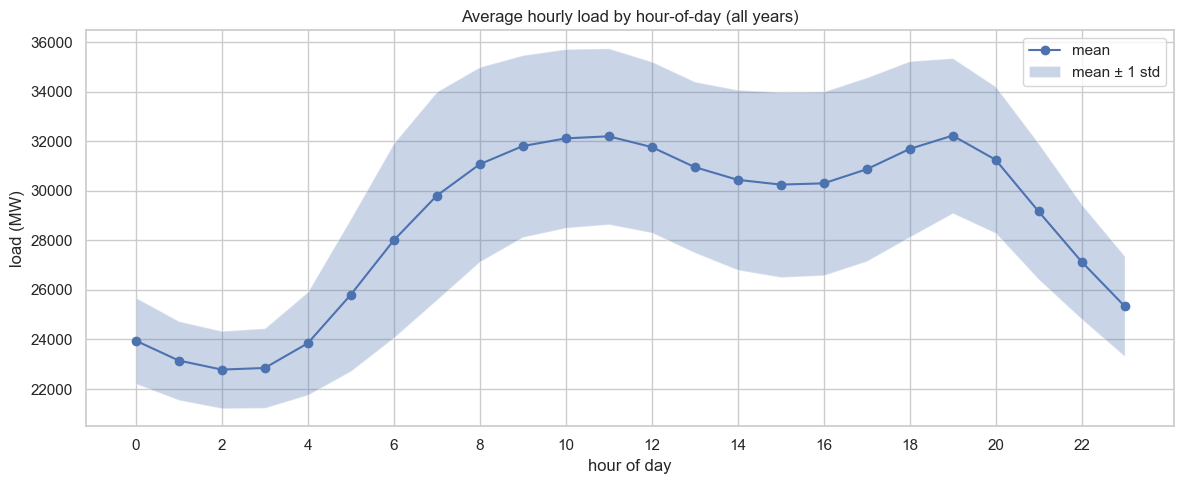

Peak hour: 19:00 (32225 MW)  |  Trough hour: 2:00 (22786 MW)
Intra-day swing: 41.4% above trough


In [6]:
hour = consumption.groupby(consumption.index.hour).agg(["mean", "std", "median"])
fig, ax = plt.subplots(figsize=(12, 5))
hour["mean"].plot(ax=ax, marker="o", label="mean")
ax.fill_between(
    hour.index,
    hour["mean"] - hour["std"],
    hour["mean"] + hour["std"],
    alpha=0.3,
    label="mean ± 1 std",
)
ax.set_xticks(range(0, 24, 2))
ax.set_title("Average hourly load by hour-of-day (all years)")
ax.set_xlabel("hour of day")
ax.set_ylabel("load (MW)")
ax.legend()
plt.tight_layout()
plt.show()

peak_h = hour["mean"].idxmax()
trough_h = hour["mean"].idxmin()
print(f"Peak hour: {peak_h}:00 ({hour.loc[peak_h, 'mean']:.0f} MW)  |  Trough hour: {trough_h}:00 ({hour.loc[trough_h, 'mean']:.0f} MW)")
print(f"Intra-day swing: {hour['mean'].max() / hour['mean'].min() - 1:.1%} above trough")

## 5. Daily/Weekly Patterns

**Question: which days of the week differ, and how big is the weekday-vs-weekend gap?**

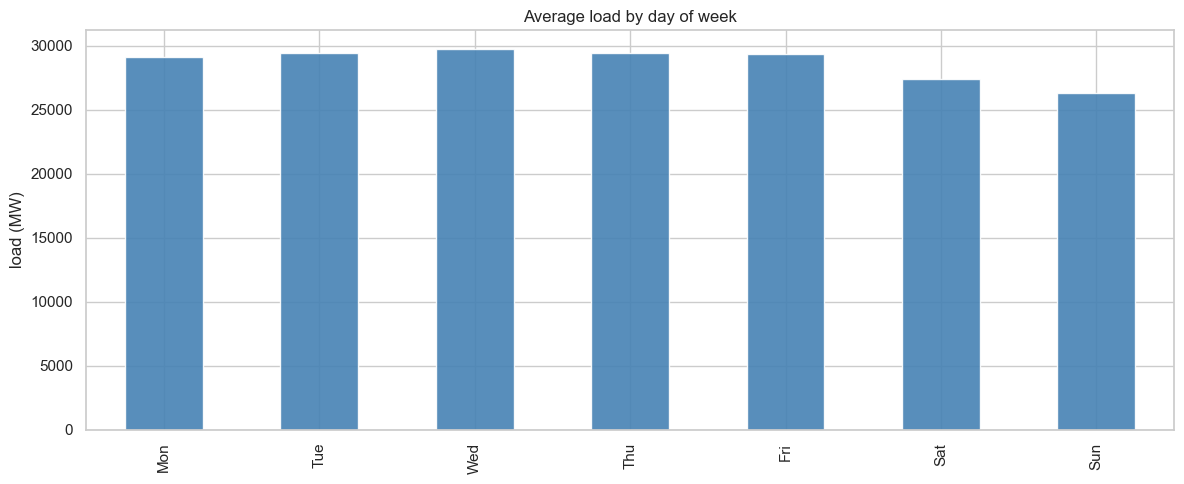

Weekday average: 29425 MW  |  Weekend average: 26879 MW  |  Weekday is 9.5% higher


In [7]:
dow = consumption.groupby(consumption.index.dayofweek).mean()
dow.index = ["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"]
fig, ax = plt.subplots(figsize=(12, 5))
dow.plot.bar(ax=ax, color="steelblue", alpha=0.9)
ax.set_title("Average load by day of week")
ax.set_ylabel("load (MW)")
plt.tight_layout()
plt.show()

weekday = dow.iloc[:5].mean()
weekend = dow.iloc[5:].mean()
print(f"Weekday average: {weekday:.0f} MW  |  Weekend average: {weekend:.0f} MW  |  "
      f"Weekday is {weekday / weekend - 1:.1%} higher")

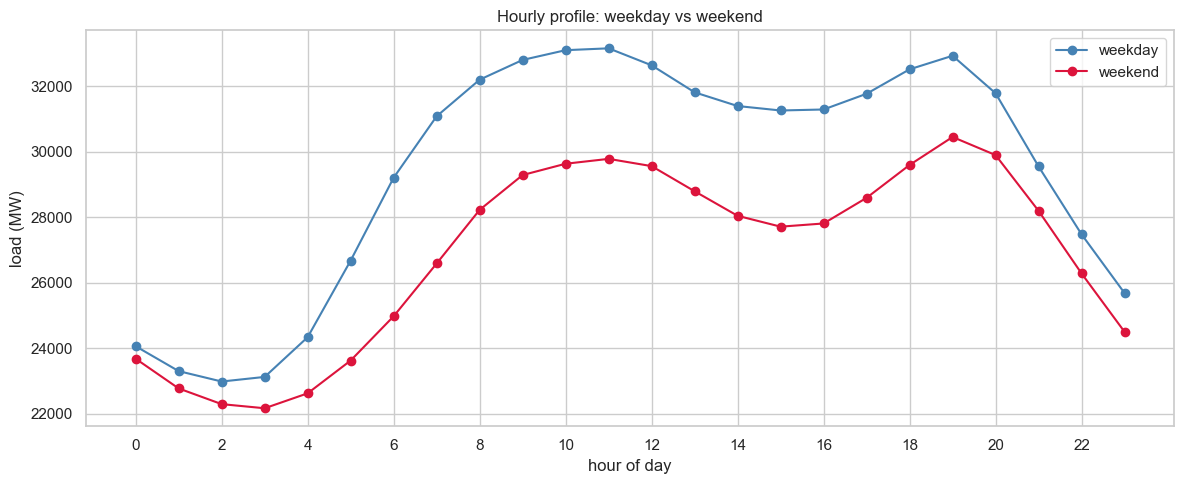

In [8]:
is_weekend = consumption.index.dayofweek >= 5
wk = consumption[~is_weekend].groupby(consumption.index[~is_weekend].hour).mean()
we = consumption[is_weekend].groupby(consumption.index[is_weekend].hour).mean()

fig, ax = plt.subplots(figsize=(12, 5))
wk.plot(ax=ax, marker="o", label="weekday", color="steelblue")
we.plot(ax=ax, marker="o", label="weekend", color="crimson")
ax.set_xticks(range(0, 24, 2))
ax.set_title("Hourly profile: weekday vs weekend")
ax.set_xlabel("hour of day")
ax.set_ylabel("load (MW)")
ax.legend()
plt.tight_layout()
plt.show()

## 6. Monthly/Seasonal Trends

**Question: how does demand evolve across months, seasons and years?** Rolling averages reveal the
slow seasonal trend under the hourly noise.

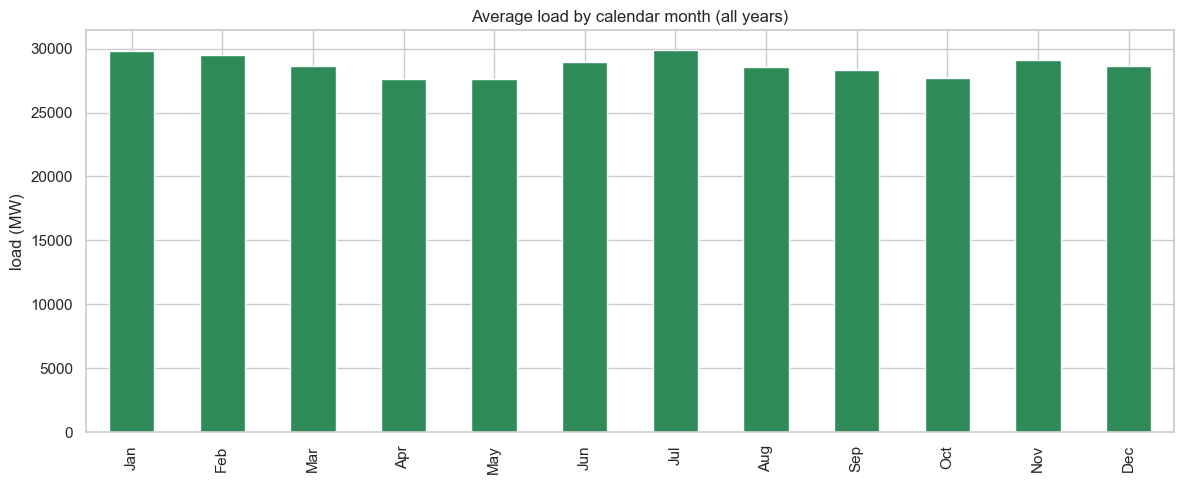

Peak month: Jul (29930 MW)  |  Trough month: Apr (27601 MW)


In [9]:
monthly = consumption.groupby(consumption.index.month).mean()
monthly.index = ["Jan", "Feb", "Mar", "Apr", "May", "Jun", "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"]
fig, ax = plt.subplots(figsize=(12, 5))
monthly.plot.bar(ax=ax, color="seagreen")
ax.set_title("Average load by calendar month (all years)")
ax.set_ylabel("load (MW)")
plt.tight_layout()
plt.show()
print("Peak month:", monthly.idxmax(), f"({monthly.max():.0f} MW)  |  Trough month:", monthly.idxmin(), f"({monthly.min():.0f} MW)")

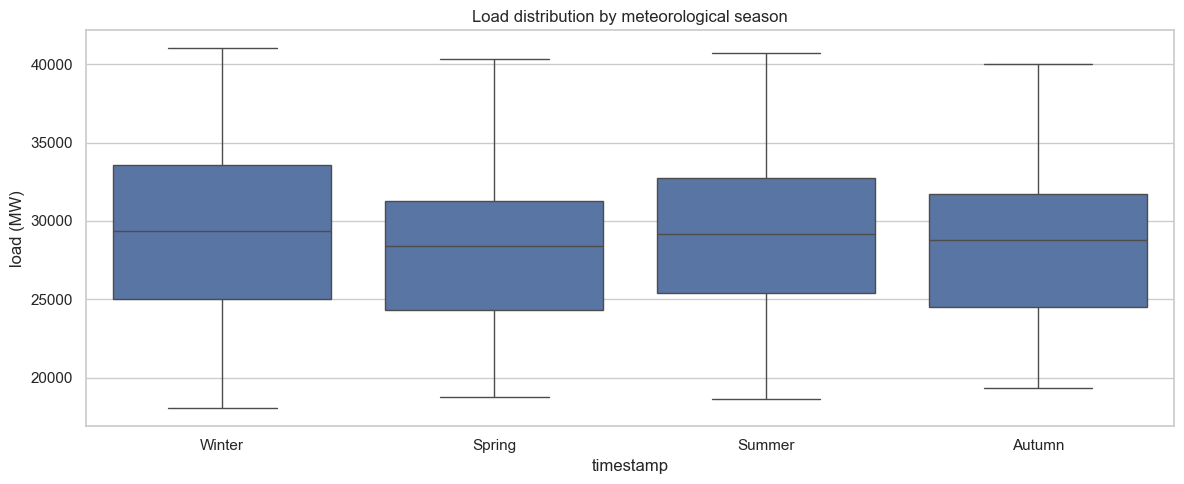

In [10]:
def season(month):
    return {1: "Winter", 2: "Winter", 12: "Winter",
            3: "Spring", 4: "Spring", 5: "Spring",
            6: "Summer", 7: "Summer", 8: "Summer",
            9: "Autumn", 10: "Autumn", 11: "Autumn"}[month]

seasons = consumption.index.month.map(season)
fig, ax = plt.subplots(figsize=(12, 5))
sns.boxplot(x=seasons, y=consumption, order=["Winter", "Spring", "Summer", "Autumn"], ax=ax)
ax.set_title("Load distribution by meteorological season")
ax.set_ylabel("load (MW)")
plt.tight_layout()
plt.show()

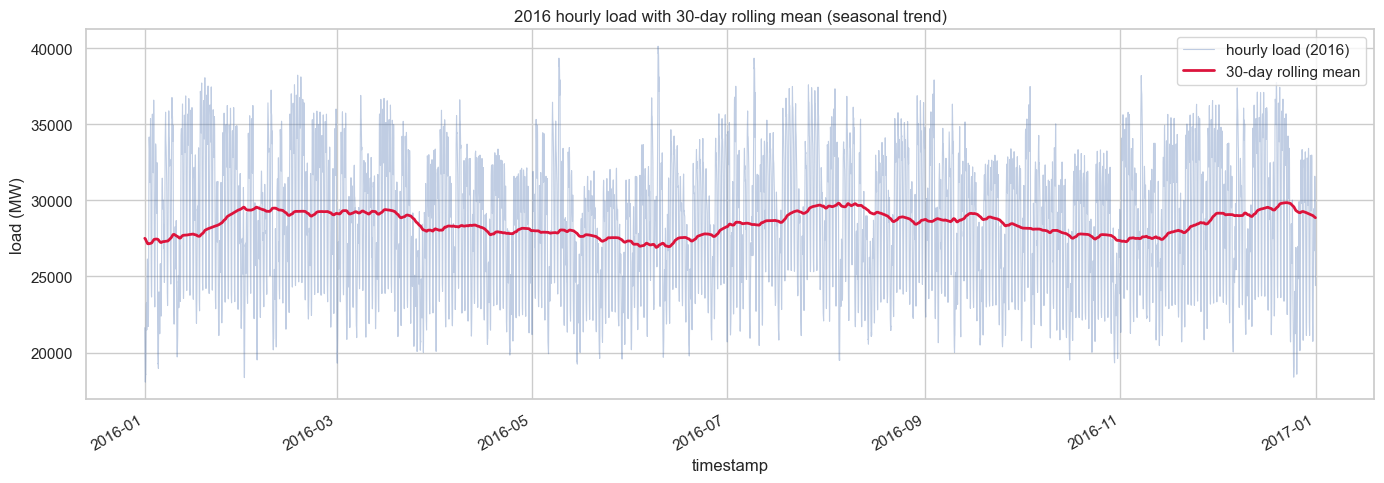

In [11]:
rolling = consumption.rolling("30D").mean()
fig, ax = plt.subplots(figsize=(14, 5))
consumption.loc["2016"].plot(ax=ax, alpha=0.35, lw=0.8, label="hourly load (2016)")
rolling.loc["2016"].plot(ax=ax, color="crimson", lw=2, label="30-day rolling mean")
ax.set_title("2016 hourly load with 30-day rolling mean (seasonal trend)")
ax.set_ylabel("load (MW)")
ax.legend()
plt.tight_layout()
plt.show()

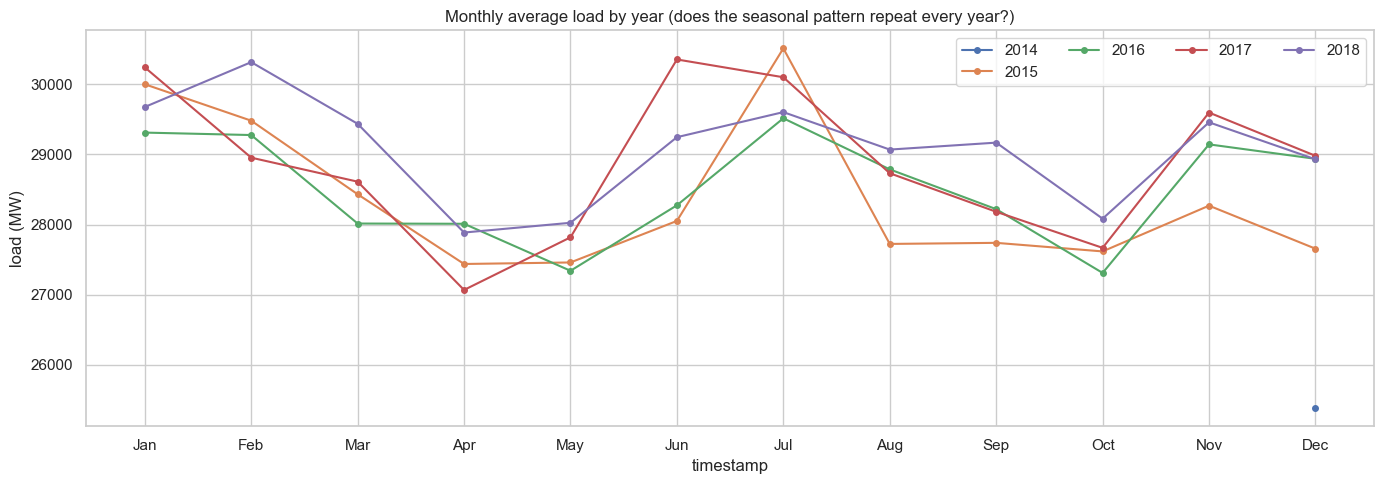

In [12]:
yearly = consumption.groupby([consumption.index.year, consumption.index.month]).mean()
fig, ax = plt.subplots(figsize=(14, 5))
for y in sorted(consumption.index.year.unique()):
    (yearly.xs(y, level=0)).plot(ax=ax, marker="o", markersize=4, lw=1.5, label=str(y))
ax.set_xticks(range(1, 13))
ax.set_xticklabels(["Jan", "Feb", "Mar", "Apr", "May", "Jun", "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"])
ax.set_title("Monthly average load by year (does the seasonal pattern repeat every year?)")
ax.set_ylabel("load (MW)")
ax.legend(ncol=4)
plt.tight_layout()
plt.show()

## 7. Correlation and Forecasting Preparation

**Question: what will make a good forecasting target/feature set?** We check autocorrelation
(memory of the series), stationarity of the trend, correlations between load and other raw columns
(forecast, generation mix, prices) and prepare a train/test split.

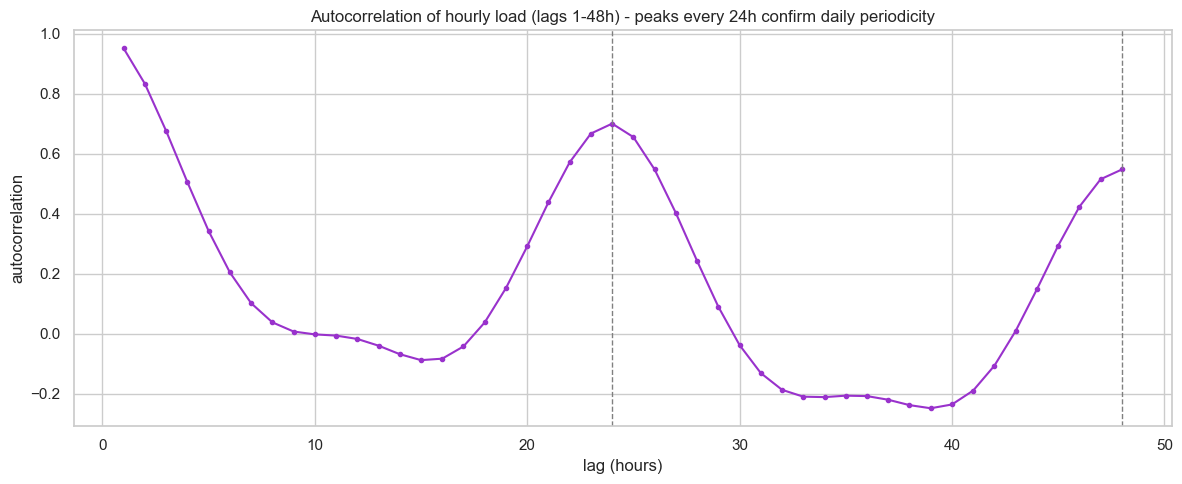

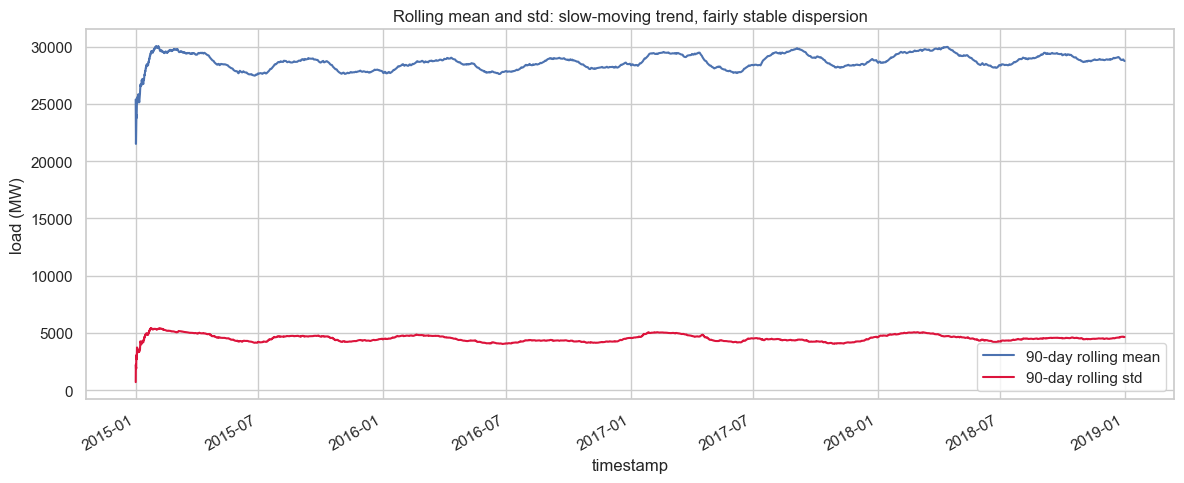

In [13]:
# How much "memory" does the series have? Autocorrelation across lags.
lags = list(range(1, 49))
acf = [consumption.autocorr(lag) for lag in lags]

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(lags, acf, marker="o", markersize=3, color="darkorchid")
ax.axvline(24, color="grey", ls="--", lw=1)
ax.axvline(48, color="grey", ls="--", lw=1)
ax.set_title("Autocorrelation of hourly load (lags 1-48h) - peaks every 24h confirm daily periodicity")
ax.set_xlabel("lag (hours)")
ax.set_ylabel("autocorrelation")
plt.tight_layout()
plt.show()

# Stationarity of trend: rolling mean/std over 90 days
roll = consumption.rolling("90D").agg(["mean", "std"])
fig, ax = plt.subplots(figsize=(12, 5))
roll["mean"].plot(ax=ax, label="90-day rolling mean")
roll["std"].plot(ax=ax, label="90-day rolling std", color="crimson")
ax.set_title("Rolling mean and std: slow-moving trend, fairly stable dispersion")
ax.set_ylabel("load (MW)")
ax.legend()
plt.tight_layout()
plt.show()

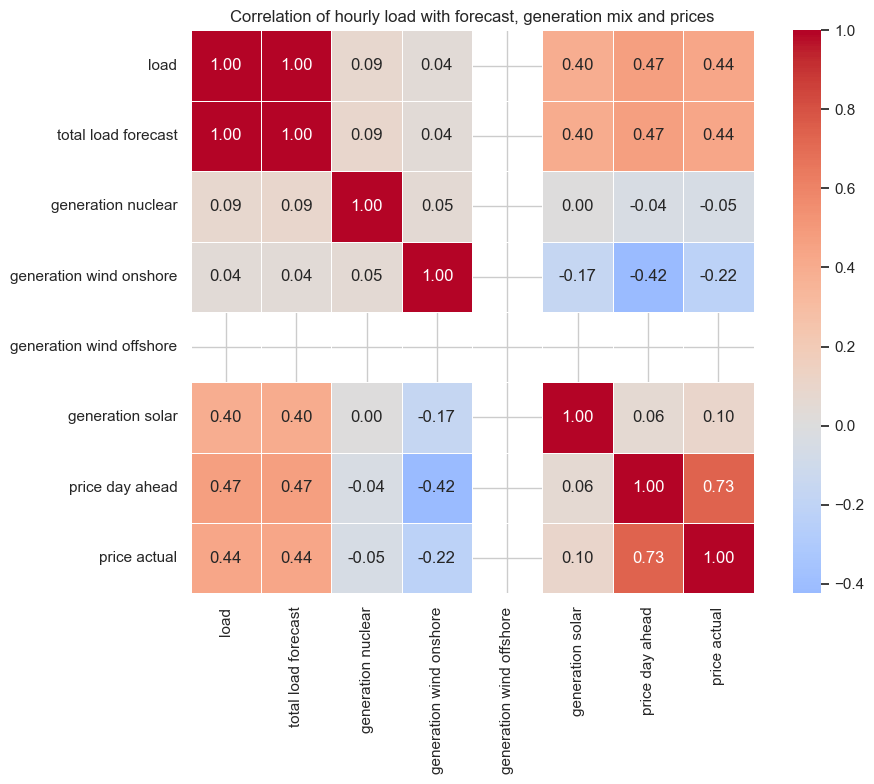

Columns used: ['load', 'total load forecast', 'generation nuclear', 'generation wind onshore', 'generation wind offshore', 'generation solar', 'price day ahead', 'price actual']


In [14]:
# Correlations: load vs other available columns (forecast, generation, prices)
candidates = ["total load forecast", "generation nuclear", "generation wind onshore",
              "generation wind offshore", "generation solar", "price day ahead", "price actual"]

num = pd.DataFrame({"load": pd.to_numeric(df["total load actual"], errors="coerce")})
for c in candidates:
    if c in df.columns:
        num[c] = pd.to_numeric(df[c], errors="coerce")
num.index = df["time"]
num = num.reindex(consumption.index)
num = num[[c for c in num.columns if num[c].notna().sum() > 1]]

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(num.corr(), annot=True, fmt=".2f", cmap="coolwarm", center=0, ax=ax,
            square=True, linewidths=0.5)
ax.set_title("Correlation of hourly load with forecast, generation mix and prices")
plt.tight_layout()
plt.show()
print("Columns used:", list(num.columns))

In [15]:
# Feature design for forecasting: calendar + lag features
features = pd.DataFrame({
    "load": consumption,
    "hour": consumption.index.hour,
    "dayofweek": consumption.index.dayofweek,
    "month": consumption.index.month,
    "lag_1h": consumption.shift(1),
    "lag_24h": consumption.shift(24),
    "lag_168h": consumption.shift(168),
    "rolling_24h_mean": consumption.rolling("24h").mean(),
}).dropna()
print("Feature matrix shape:", features.shape)
features.head()

Feature matrix shape: (34860, 8)


,load,hour,dayofweek,month,lag_1h,lag_24h,lag_168h,rolling_24h_mean
timestamp,,,,,,,,
2015-01-08 05:00:00,22551.0,5,3,1,22361.0,26992.0,25385.0,31073.375000
2015-01-08 06:00:00,22543.0,6,3,1,22551.0,28625.0,24382.0,30819.958333
2015-01-08 07:00:00,24042.0,7,3,1,22543.0,31015.0,22734.0,30529.416667
2015-01-08 08:00:00,25932.0,8,3,1,24042.0,33276.0,21286.0,30223.416667
2015-01-08 09:00:00,27664.0,9,3,1,25932.0,34221.0,20264.0,29950.208333


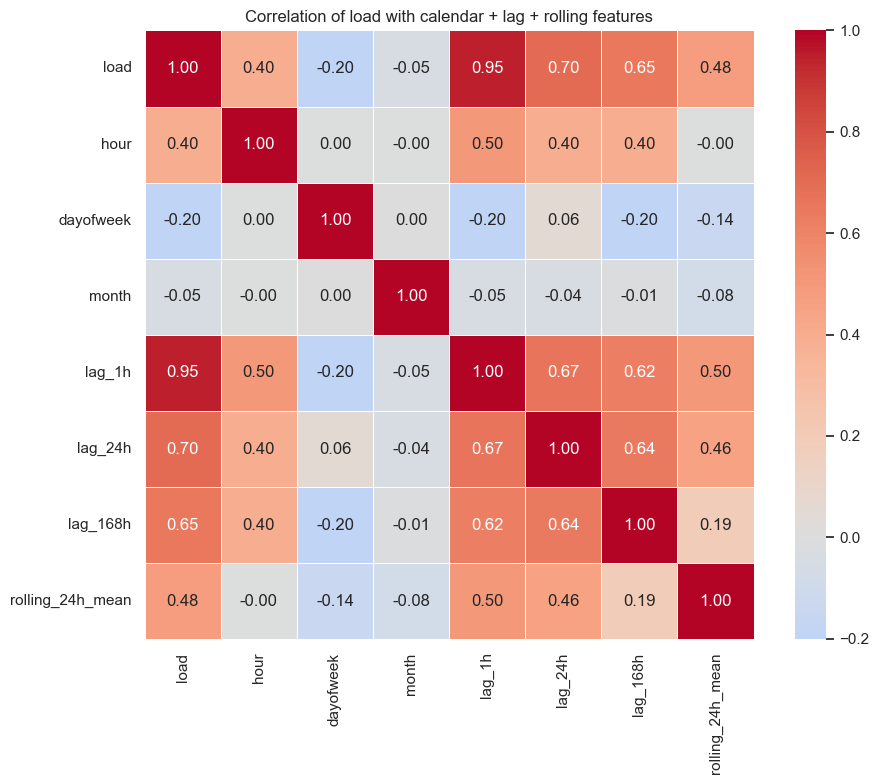

Train: 2014-12-31 23:00:00 -> 2018-03-14 22:00:00  (28,022 records)
Test:  2018-03-14 23:00:00 -> 2018-12-31 22:00:00  (7,006 records)


In [16]:
fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(features.corr(), annot=True, fmt=".2f", cmap="coolwarm", center=0, ax=ax, square=True, linewidths=0.5)
ax.set_title("Correlation of load with calendar + lag + rolling features")
plt.tight_layout()
plt.show()

# Train/test split (temporal - never shuffle time series)
split = int(len(consumption) * 0.8)
train, test = consumption.iloc[:split], consumption.iloc[split:]
print(f"Train: {train.index.min()} -> {train.index.max()}  ({len(train):,} records)")
print(f"Test:  {test.index.min()} -> {test.index.max()}  ({len(test):,} records)")